# **Data Diri**

Nama: Meakhel Gunawan

Email : meakhel220504@gmail.com

# <font color='yellow'> **Import Library**</font>

In [1]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00


In [2]:
!pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.1 MB/s eta 0:00:00


In [3]:
!pip install emoji

In [4]:
# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews, Sort, reviews_all
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 116
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia
from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

# Library preprocess
import emoji
import csv
import requests
from io import StringIO
from wordcloud import WordCloud

# Library modeling
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate, Layer
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)
import torch

2026-02-04 23:43:11.832319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770248592.019324      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770248592.070086      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770248592.506903      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770248592.506947      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770248592.506950      55 computation_placer.cc:177] computation placer alr

In [5]:
import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt_tab')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stop words) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#  <font color='yellow'> **Load Dataset**</font>

In [8]:
# Membuat DataFrame dari hasil scrapreview
app_reviews_df = pd.read_csv('ulasan_gemini.csv')

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

/tmp/ipykernel_55/3985575180.py:2: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  app_reviews_df = pd.read_csv('ulasan_gemini.csv')


In [9]:
# Menampilkan lima baris pertama dari DataFrame app_reviews_df
app_reviews_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,3965ffa1-1167-4903-9a92-4f5b1f021e58,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"yang jadi permasalahan, saya ingin mencari inf...",1,14,1.0.795460806,2026-01-27 11:32:44,NaN,NaN,1.0.795460806
1,7090c23b-025f-4c4f-99f9-a0d6855cf086,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Apk bagus skli, dan sangat menyenangkan bisa m...",5,47,1.0.795460806,2026-01-24 09:18:48,NaN,NaN,1.0.795460806
2,cd44634e-5c9d-4d3e-8cbe-a70fb03a5b8b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kenapa ya, makin lama semakin banyak eror nya?...",4,4,1.0.795460806,2026-01-28 09:03:40,NaN,NaN,1.0.795460806
3,c92b2148-10ff-4715-98c0-3581debf07fa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,nurut aku sih udah bagus gak ada batasan limit...,5,1120,1.0.795460806,2025-12-02 13:35:21,NaN,NaN,1.0.795460806
4,fe132140-5aae-4b7e-9607-35729992fe09,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Berapa batas penggunaan token setiap hari untu...,1,1115,1.0.795460806,2025-09-17 02:53:19,NaN,NaN,1.0.795460806
...,...,...,...,...,...,...,...,...,...,...,...
89995,4baf9905-6d6d-498e-a3a3-6d59798005af,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu,5,0,1.0.795460806,2025-09-09 15:11:57,NaN,NaN,1.0.795460806
89996,4fbd7cdd-f87a-4151-8e28-ea7bb00f0aa3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu,5,0,1.0.795460806,2025-09-05 15:51:50,NaN,NaN,1.0.795460806
89997,dc9b3aa0-deec-4a01-a8fd-25c6fa11501e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat menggangu saat bermain game,1,0,NaN,2025-09-18 03:02:45,NaN,NaN,NaN
89998,231e47fa-88fb-4cc6-94ac-da6b0931b528,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu,5,0,1.0.795460806,2025-09-10 23:00:16,NaN,NaN,1.0.795460806


In [10]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              90000 non-null  object
 1   userName              90000 non-null  object
 2   userImage             90000 non-null  object
 3   content               90000 non-null  object
 4   score                 90000 non-null  int64 
 5   thumbsUpCount         90000 non-null  int64 
 6   reviewCreatedVersion  82032 non-null  object
 7   at                    90000 non-null  object
 8   replyContent          3 non-null      object
 9   repliedAt             3 non-null      object
 10  appVersion            82032 non-null  object
dtypes: int64(2), object(9)
memory usage: 7.6+ MB


In [11]:
# Mengecek nilai null
app_reviews_df.isnull().sum()

reviewId                    0
userName                    0
userImage                   0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion     7968
at                          0
replyContent            89997
repliedAt               89997
appVersion               7968
dtype: int64

In [12]:
# Menghapus kolom-kolom yang memiliki banyak nilai NaN, dan juga memang kurang diperlukan untuk Analisis Sentimen
app_reviews_df_new = app_reviews_df.drop(columns=['reviewCreatedVersion','replyContent','repliedAt', 'appVersion'])

In [13]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df_new
clean_df = app_reviews_df_new.dropna()

In [14]:
# Menampilkan informasi tentang DataFrame clean_df setelah membersihkan nilai yang hilang (NaN)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   reviewId       90000 non-null  object
 1   userName       90000 non-null  object
 2   userImage      90000 non-null  object
 3   content        90000 non-null  object
 4   score          90000 non-null  int64 
 5   thumbsUpCount  90000 non-null  int64 
 6   at             90000 non-null  object
dtypes: int64(2), object(5)
memory usage: 4.8+ MB


In [15]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

# Mengecek nilai null
clean_df.isnull().sum()

reviewId         0
userName         0
userImage        0
content          0
score            0
thumbsUpCount    0
at               0
dtype: int64

In [16]:
# Menampilkan informasi tentang DataFrame clean_df setelah membersihkan data duplikat
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   reviewId       30000 non-null  object
 1   userName       30000 non-null  object
 2   userImage      30000 non-null  object
 3   content        30000 non-null  object
 4   score          30000 non-null  int64 
 5   thumbsUpCount  30000 non-null  int64 
 6   at             30000 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.8+ MB


#  <font color='yellow'> **Preprocessing**</font>

### 1. Menghapus emoji

In [17]:
# Fungsi untuk mendeteksi emotikon
def contains_emoji(content):
    return any(char in emoji.EMOJI_DATA for char in content)

# Menerapkan fungsi untuk mendeteksi baris yang mengandung emotikon
clean_df['has_emoji'] = clean_df['content'].apply(contains_emoji)

# Menghapus baris yang mengandung emotikon
clean_df = clean_df[~clean_df['has_emoji']].drop(columns=['has_emoji'])

### 2. Pembersihan dan pemfilteran data

In [18]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)  # Remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text)  # Remove hashtags
    text = re.sub(r'RT[\s]', '', text)  # Remove RT
    text = re.sub(r'http\S+', '', text)  # Remove links
    text = re.sub(r'[0-9]+', '', text)  # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = text.replace('\n', ' ')  # Replace new lines with space
    text = text.strip()  # Remove leading/trailing spaces
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove all punctuations
    text = text.strip(' ') # remove characters space from both left and right text
    return text

def casefoldingText(text): # Converting all the characters in a text into lower case
    text = text.lower()
    return text

def tokenizingText(text): # Tokenizing or splitting a string, text into a list of tokens
    text = word_tokenize(text)
    return text

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian') + stopwords.words('english'))
    listStopwords.update(['iya', 'yaa', 'gak', 'nya', 'na', 'sih', 'ku', 'di', 'ga', 'ya', 'gaa', 'loh', 'kah', 'woi', 'woii', 'woy'])

    filtered_text = [word for word in text if word not in listStopwords]
    return filtered_text

def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    if isinstance(text, str):  # Jika input string, tokenisasi dulu
        words = text.split()
    else:
        words = text

    stemmed_words = [stemmer.stem(word) for word in words]
    return stemmed_words  # Output tetap list untuk menjaga kompatibilitas

def toSentence(list_words): # Convert list of words into sentence
    sentence = ' '.join(word for word in list_words)
    return sentence

In [19]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "ngk": "tidak", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin", "bagu": "bagus", "eror": "error", "krna": "karena", "ksh": "kasih", "sgat": "sangat", "bget": "banget"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [20]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Melakukan stemmed  dan menyimpannya di 'text_stemmed'
# clean_df['text_stemmed'] = clean_df['text_stopword'].apply(stemmingText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
# clean_df['text_akhir'] = clean_df['text_stemmed'].apply(toSentence)
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [21]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,at,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,3965ffa1-1167-4903-9a92-4f5b1f021e58,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"yang jadi permasalahan, saya ingin mencari inf...",1,14,2026-01-27 11:32:44,yang jadi permasalahan saya ingin mencari info...,yang jadi permasalahan saya ingin mencari info...,yang jadi permasalahan saya ingin mencari info...,"[yang, jadi, permasalahan, saya, ingin, mencar...","[permasalahan, mencari, informasi, responnya, ...",permasalahan mencari informasi responnya tibat...
1,7090c23b-025f-4c4f-99f9-a0d6855cf086,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Apk bagus skli, dan sangat menyenangkan bisa m...",5,47,2026-01-24 09:18:48,Apk bagus skli dan sangat menyenangkan bisa me...,apk bagus skli dan sangat menyenangkan bisa me...,apk bagus skli dan sangat menyenangkan bisa me...,"[apk, bagus, skli, dan, sangat, menyenangkan, ...","[apk, bagus, skli, menyenangkan, merubah, awal...",apk bagus skli menyenangkan merubah awal² hasi...
2,cd44634e-5c9d-4d3e-8cbe-a70fb03a5b8b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kenapa ya, makin lama semakin banyak eror nya?...",4,4,2026-01-28 09:03:40,kenapa ya makin lama semakin banyak eror nya m...,kenapa ya makin lama semakin banyak eror nya m...,kenapa iya makin lama semakin banyak error nya...,"[kenapa, iya, makin, lama, semakin, banyak, er...","[error, gambar, analisis, dapatnya, langsung, ...",error gambar analisis dapatnya langsung gambar...
3,c92b2148-10ff-4715-98c0-3581debf07fa,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,nurut aku sih udah bagus gak ada batasan limit...,5,1120,2025-12-02 13:35:21,nurut aku sih udah bagus gak ada batasan limit...,nurut aku sih udah bagus gak ada batasan limit...,nurut aku sih sudah bagus gak ada batasan limi...,"[nurut, aku, sih, sudah, bagus, gak, ada, bata...","[nurut, bagus, batasan, limit, mengirim, ketik...",nurut bagus batasan limit mengirim ketikan pes...
4,fe132140-5aae-4b7e-9607-35729992fe09,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Berapa batas penggunaan token setiap hari untu...,1,1115,2025-09-17 02:53:19,Berapa batas penggunaan token setiap hari untu...,berapa batas penggunaan token setiap hari untu...,berapa batas penggunaan token setiap hari untu...,"[berapa, batas, penggunaan, token, setiap, har...","[batas, penggunaan, token, versi, ai, profesio...",batas penggunaan token versi ai profesional ai...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4baf9905-6d6d-498e-a3a3-6d59798005af,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu,5,0,2025-09-09 15:11:57,sangat membantu,sangat membantu,sangat membantu,"[sangat, membantu]",[membantu],membantu
29996,4fbd7cdd-f87a-4151-8e28-ea7bb00f0aa3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu,5,0,2025-09-05 15:51:50,sangat membantu,sangat membantu,sangat membantu,"[sangat, membantu]",[membantu],membantu
29997,dc9b3aa0-deec-4a01-a8fd-25c6fa11501e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat menggangu saat bermain game,1,0,2025-09-18 03:02:45,sangat menggangu saat bermain game,sangat menggangu saat bermain game,sangat menggangu saat bermain game,"[sangat, menggangu, saat, bermain, game]","[menggangu, bermain, game]",menggangu bermain game
29998,231e47fa-88fb-4cc6-94ac-da6b0931b528,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu,5,0,2025-09-10 23:00:16,sangat membantu,sangat membantu,sangat membantu,"[sangat, membantu]",[membantu],membantu


In [22]:
clean_df['score'].unique()

array([1, 5, 4, 2, 3])

#  <font color='yellow'> **Pelabelan**</font>

In [23]:
# Loads positive lexicon data from GitHub
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Loads negative lexicon data from GitHub
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya ke dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [24]:
# Function to determine sentiment polarity of tweets
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score > 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif

    elif (score==0):
        polarity = 'neutral'
    # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [25]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    10768
negative    10705
neutral      6162
Name: count, dtype: int64


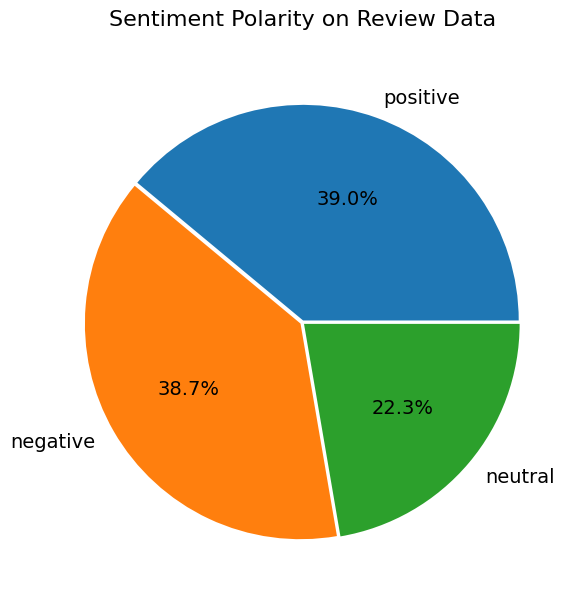

In [26]:
# Membuat objek gambar dan sumbu dengan ukuran (7, 7) inci.
fig, ax = plt.subplots(figsize=(7, 7))

# Mengambil jumlah data polaritas sentimen dari DataFrame 'clean_df' dan menyimpannya dalam list 'sizes'.
sizes = [count for count in clean_df['polarity'].value_counts()]

# Mengambil label atau kategori sentimen dari DataFrame 'clean_df' dan menyimpannya dalam list 'labels'.
labels = list(clean_df['polarity'].value_counts().index)

# Menentukan seberapa jauh potongan dari pie chart akan ditarik (0.01 artinya potongan pertama akan sedikit terpisah).
explode = (0.01, 0.01, 0.01)

# Membuat pie chart dengan data 'sizes', 'labels', dan 'explode' yang telah ditentukan.
# Autopct digunakan untuk menampilkan persentase di dalam setiap potongan pie.
# Textprops digunakan untuk mengatur ukuran font teks dalam pie chart.
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})

# Menetapkan judul untuk pie chart dengan ukuran font dan jarak (padding) tertentu.
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)

# Menampilkan pie chart.
plt.show()

In [27]:
def get_filtered_tweets(df, polarity_type):
    # Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
    pd.set_option('display.max_colwidth', 3000)

    # Membuat DataFrame baru yang hanya berisi tweet dengan polaritas tertentu.
    filtered_tweets = df[df['polarity'] == polarity_type]

    # Memilih hanya kolom-kolom tertentu dari DataFrame.
    filtered_tweets = filtered_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

    # Mengurutkan DataFrame berdasarkan 'polarity_score' secara menurun untuk positif, menaik untuk negatif/netral.
    if polarity_type == 'positive':
        filtered_tweets = filtered_tweets.sort_values(by='polarity_score', ascending=False)
    elif polarity_type == 'negative':
        filtered_tweets = filtered_tweets.sort_values(by='polarity_score', ascending=True)
        filtered_tweets = filtered_tweets[0:10] # Ambil 10 teratas untuk negatif
    elif polarity_type == 'neutral':
        filtered_tweets = filtered_tweets.sort_values(by='polarity_score', ascending=True)
        filtered_tweets = filtered_tweets[0:10] # Ambil 10 teratas untuk netral

    # Mengatur ulang indeks DataFrame agar dimulai dari 0.
    filtered_tweets = filtered_tweets.reset_index(drop=True)

    # Menambahkan 1 ke semua indeks DataFrame.
    filtered_tweets.index += 1

    return filtered_tweets

# Memanggil fungsi untuk polaritas positif
positive_tweets = get_filtered_tweets(clean_df, 'positive')

# Memanggil fungsi untuk polaritas negatif
negative_tweets = get_filtered_tweets(clean_df, 'negative')

# Memanggil fungsi untuk polaritas netral
neutral_tweets = get_filtered_tweets(clean_df, 'neutral')

In [28]:
def generate_wordcloud(df, text_column, title):
    """
    Fungsi untuk membuat WordCloud dari dataframe tertentu.

    Parameters:
    df : pandas.DataFrame
        DataFrame sumber data
    text_column : str
        Nama kolom yang berisi token kata (list kata)
    title : str
        Judul WordCloud
    """

    # Menggabungkan semua kata menjadi satu string
    list_words = " ".join(
        word
        for tweet in df[text_column]
        for word in tweet
    )

    # Membuat WordCloud
    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color='white',
        min_font_size=10
    ).generate(list_words)

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title(title, fontsize=18)
    ax.grid(False)
    ax.imshow(wordcloud)
    fig.tight_layout(pad=0)
    ax.axis('off')
    plt.show()


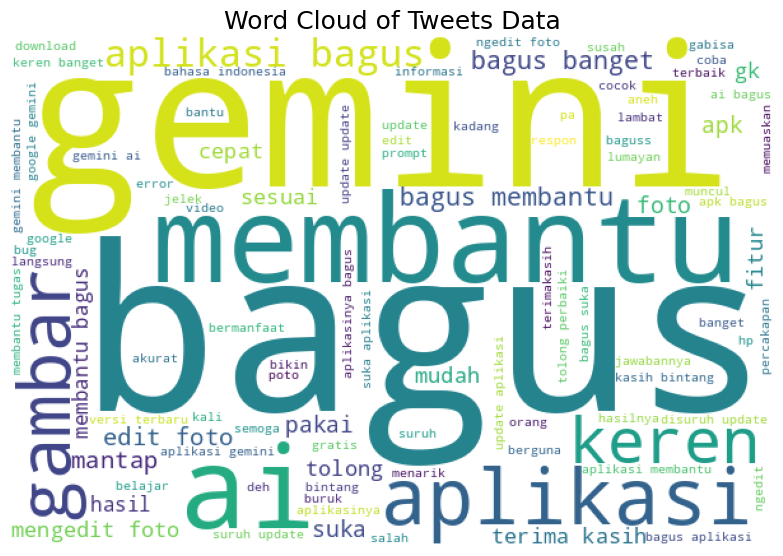

In [29]:
# Membuat WordCloud untuk clean_df.
generate_wordcloud(clean_df, 'text_stopword', 'Word Cloud of Tweets Data')

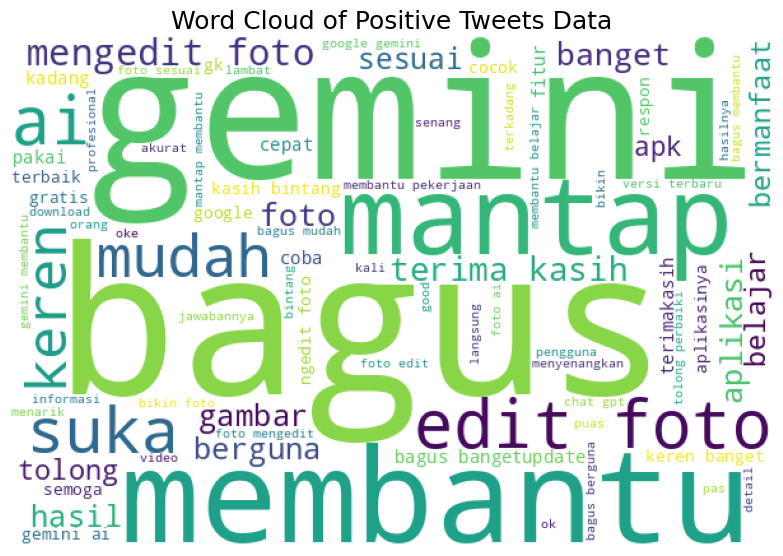

In [30]:
# Membuat WordCloud untuk ulasan positif.
generate_wordcloud(positive_tweets, 'text_stopword', 'Word Cloud of Positive Tweets Data')

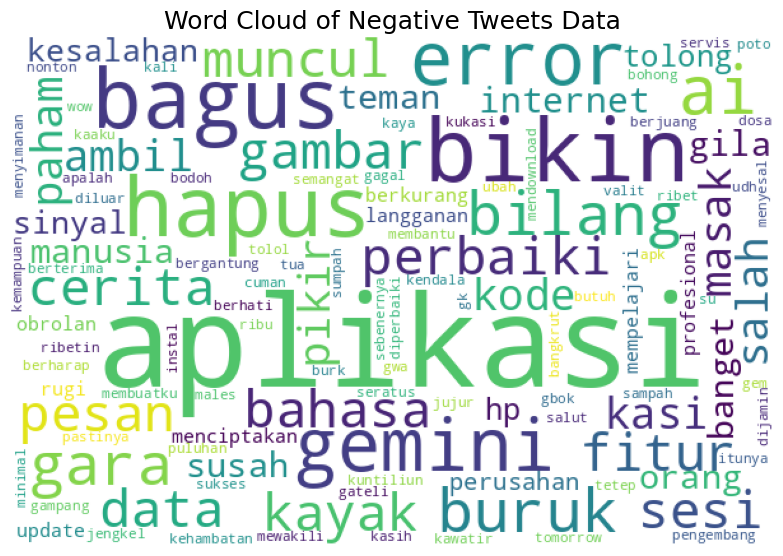

In [31]:
# Membuat WordCloud untuk ulasan negatif.
generate_wordcloud(negative_tweets, 'text_stopword', 'Word Cloud of Negative Tweets Data')

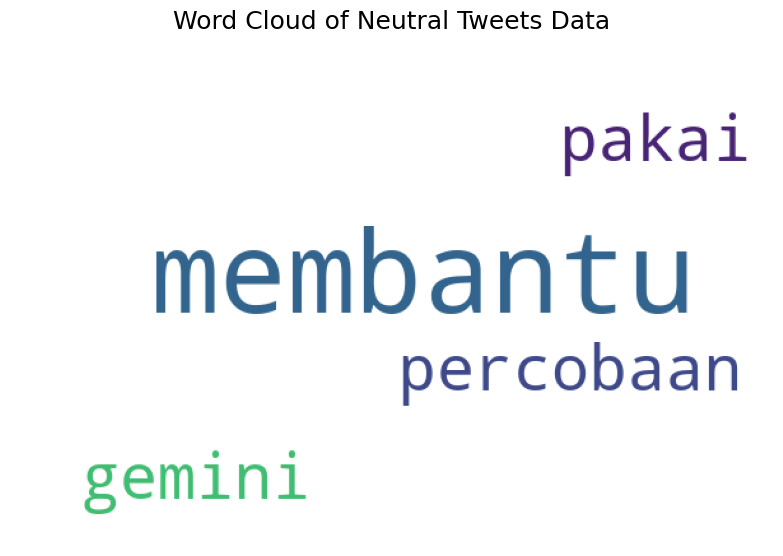

In [32]:
# Membuat WordCloud untuk ulasan netral.
generate_wordcloud(neutral_tweets, 'text_stopword', 'Word Cloud of Neutral Tweets Data')

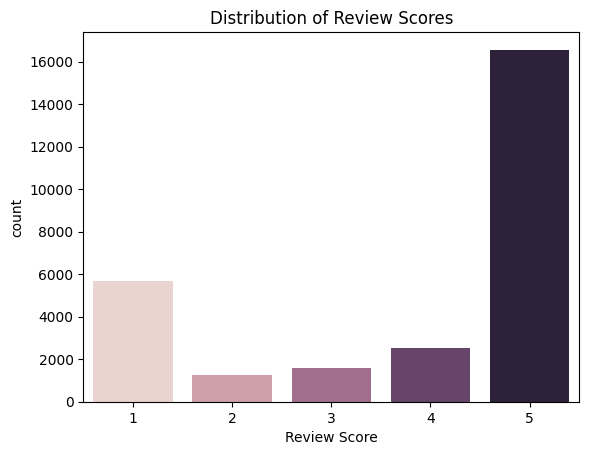

In [33]:
sns.countplot(x='score', data=clean_df, hue='score', dodge=False)
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.legend([],[], frameon=False)

plt.show()

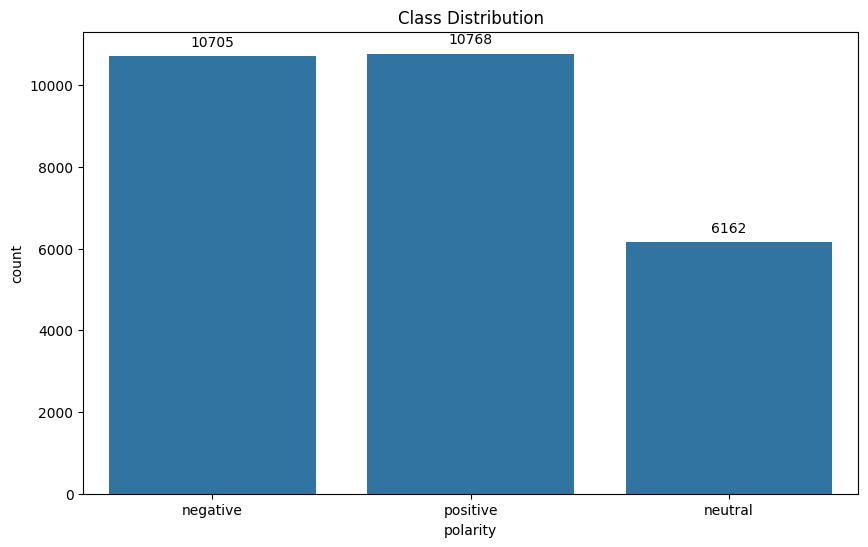

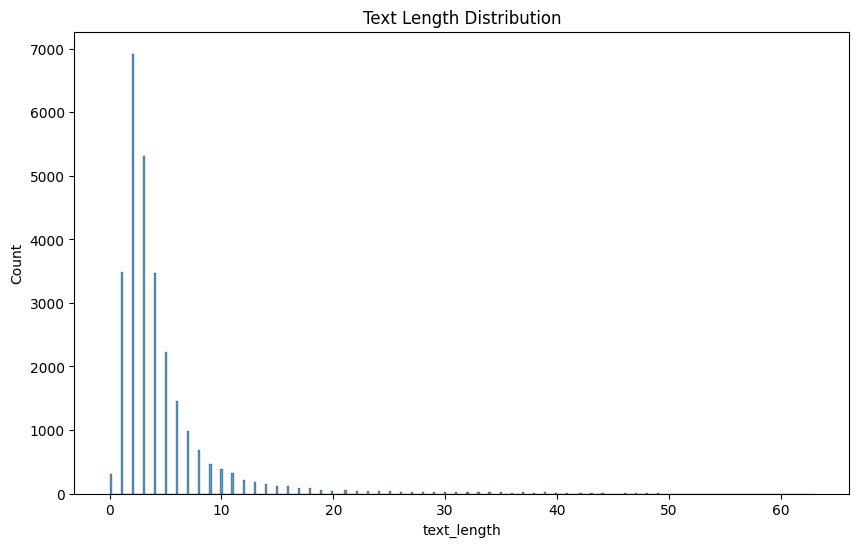

In [34]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Check class distribution
class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# Set the figure size
plt.figure(figsize=(10, 6))

# Visualize text length distribution
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'])
plt.title('Text Length Distribution')
plt.show()

In [35]:
def plot_top_tfidf_words(df, text_column, title, top_n=20,
                         max_features=None, min_df=1, max_df=1.0):
    """
    Fungsi untuk memvisualisasikan kata dengan skor TF-IDF tertinggi.

    Parameters:
    df : pandas.DataFrame
        DataFrame sumber data
    text_column : str
        Nama kolom teks
    title : str
        Judul grafik
    top_n : int
        Jumlah kata teratas yang ditampilkan
    max_features : int
        Jumlah maksimum fitur TF-IDF (opsional)
    min_df : int/float
        Minimum document frequency
    max_df : float
        Maximum document frequency
    """

    # Inisialisasi TF-IDF
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        min_df=min_df,
        max_df=max_df
    )

    # Transformasi teks
    X = vectorizer.fit_transform(df[text_column])

    # Konversi menjadi DataFrame
    tfidf_df = pd.DataFrame(
        X.toarray(),
        columns=vectorizer.get_feature_names_out()
    )

    # Hitung total skor tiap kata
    tfidf_sum = (
        tfidf_df.sum()
        .reset_index(name='jumlah')
        .sort_values('jumlah', ascending=False)
        .head(top_n)
    )

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x='jumlah', y='index', data=tfidf_sum)
    plt.title(title)
    plt.show()


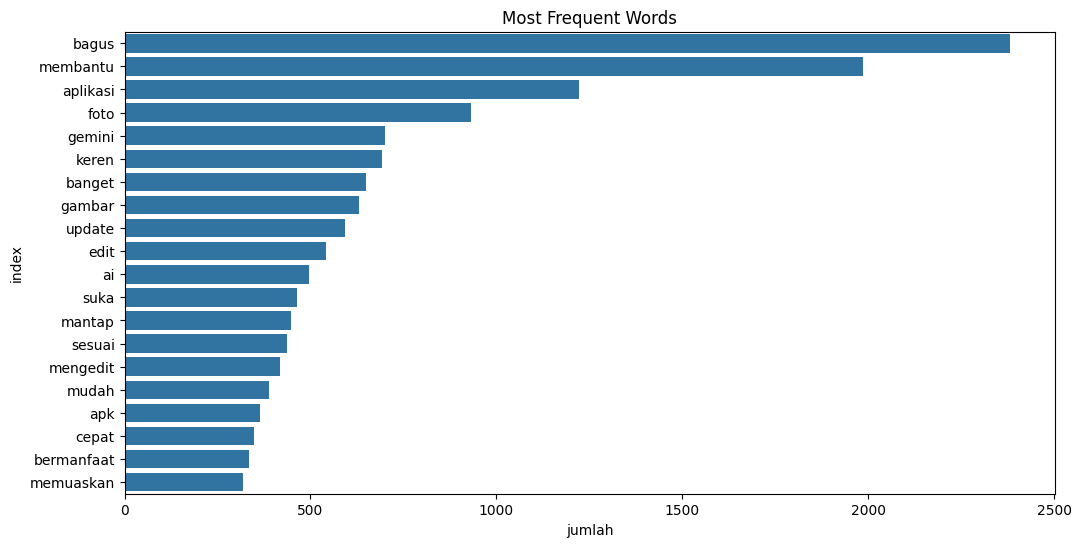

In [36]:
# Visualisasi most frequent words untuk clean_df.
plot_top_tfidf_words(
    clean_df,
    'text_akhir',
    'Most Frequent Words'
)

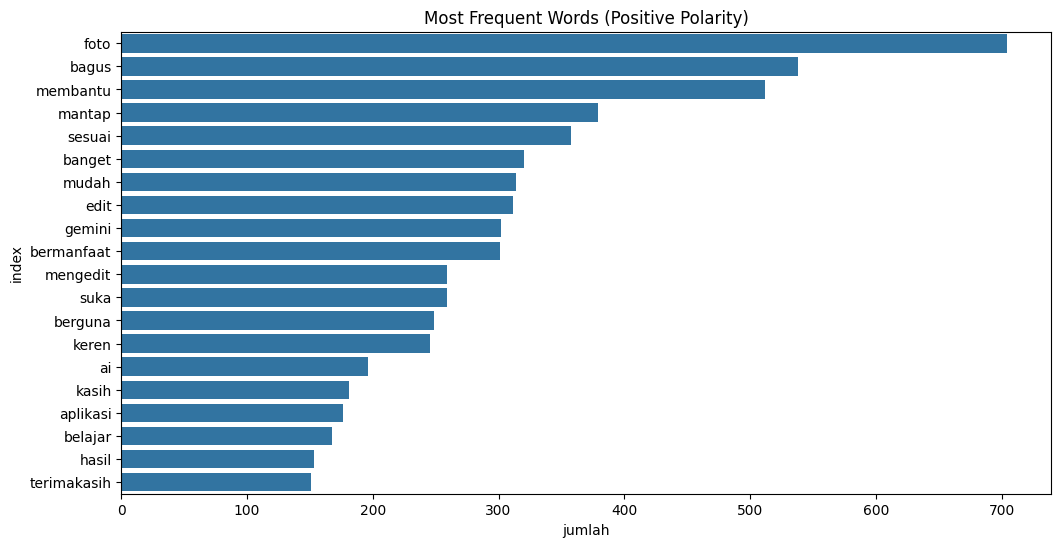

In [37]:
# Visualisasi most frequent words untuk ulasan positif.
plot_top_tfidf_words(
    positive_tweets,
    'text_akhir',
    'Most Frequent Words (Positive Polarity)'
)

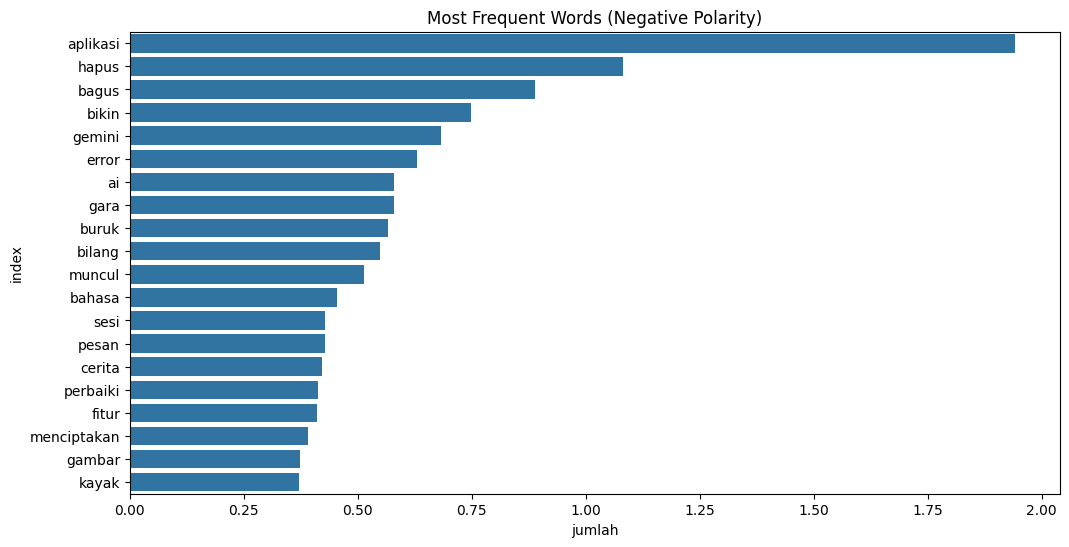

In [38]:
# Visualisasi most frequent words untuk ulasan negatif.
plot_top_tfidf_words(
    negative_tweets,
    'text_akhir',
    'Most Frequent Words (Negative Polarity)'
)

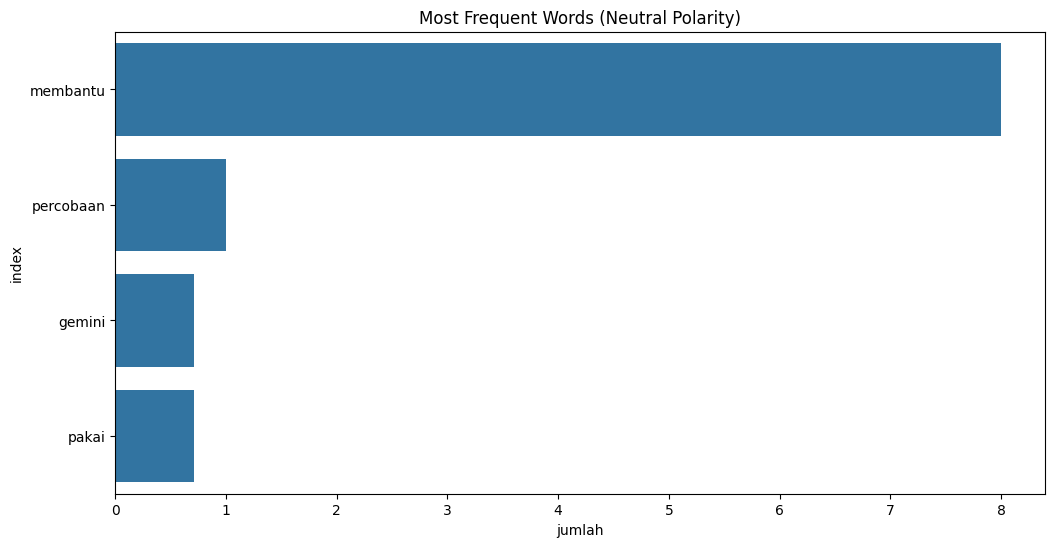

In [39]:
# Visualisasi most frequent words untuk ulasan netral.
plot_top_tfidf_words(
    neutral_tweets,
    'text_akhir',
    'Most Frequent Words (Neutral Polarity)'
)

In [40]:
# Buat mapping dari label ke integer
label_mapping = {"positive": 1, "negative": 0, "neutral": 2}

# Ubah nilai kolom 'label' menjadi integer menggunakan mapping
clean_df['label'] = clean_df['polarity'].map(label_mapping)
clean_df['label'] = clean_df['label'].astype(int)

#  <font color='yellow'> **Modelling**</font>

1. Linear SVM + TF-IDF (n-gram) + class_weight (90/10)
2. Bidirectional LSTM + Attention + Trainable Embedding Layer (80/20)
3. TextCNN + Attention + Trainable Embedding (80/20)

In [41]:
print(f'Terdapat {clean_df.shape[0]} sample data')

Terdapat 27635 sample data


In [42]:
clean_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,at,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,text_length,label
0,3965ffa1-1167-4903-9a92-4f5b1f021e58,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"yang jadi permasalahan, saya ingin mencari informasi, tapi responnya tiba-tiba bukan tentang informasi yang saya inginkan, dan ketika saya ingin membuat gambar, responnya malah tidak bisa ""sorry, i can't edit images."" MUAKK! udah coba berkali-kali sama aja. bahkan jika ingin membuat gambar sangat susah, lagi lagi ""sorry, i can't edit images."" ga sesuai ekspetasi",1,14,2026-01-27 11:32:44,yang jadi permasalahan saya ingin mencari informasi tapi responnya tibatiba bukan tentang informasi yang saya inginkan dan ketika saya ingin membuat gambar responnya malah tidak bisa sorry i cant edit images MUAKK udah coba berkalikali sama aja bahkan jika ingin membuat gambar sangat susah lagi lagi sorry i cant edit images ga sesuai ekspetasi,yang jadi permasalahan saya ingin mencari informasi tapi responnya tibatiba bukan tentang informasi yang saya inginkan dan ketika saya ingin membuat gambar responnya malah tidak bisa sorry i cant edit images muakk udah coba berkalikali sama aja bahkan jika ingin membuat gambar sangat susah lagi lagi sorry i cant edit images ga sesuai ekspetasi,yang jadi permasalahan saya ingin mencari informasi tapi responnya tibatiba bukan tentang informasi yang saya inginkan dan ketika saya ingin membuat gambar responnya bahkan tidak bisa maaf i cant edit images muakk sudah coba berkalikali sama saja bahkan jika ingin membuat gambar sangat susah lagi lagi maaf i cant edit images ga sesuai ekspetasi,"[yang, jadi, permasalahan, saya, ingin, mencari, informasi, tapi, responnya, tibatiba, bukan, tentang, informasi, yang, saya, inginkan, dan, ketika, saya, ingin, membuat, gambar, responnya, bahkan, tidak, bisa, maaf, i, cant, edit, images, muakk, sudah, coba, berkalikali, sama, saja, bahkan, jika, ingin, membuat, gambar, sangat, susah, lagi, lagi, maaf, i, cant, edit, images, ga, sesuai, ekspetasi]","[permasalahan, mencari, informasi, responnya, tibatiba, informasi, gambar, responnya, maaf, cant, edit, images, muakk, coba, berkalikali, gambar, susah, maaf, cant, edit, images, sesuai, ekspetasi]",permasalahan mencari informasi responnya tibatiba informasi gambar responnya maaf cant edit images muakk coba berkalikali gambar susah maaf cant edit images sesuai ekspetasi,-8,negative,23,0
1,7090c23b-025f-4c4f-99f9-a0d6855cf086,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Apk bagus skli, dan sangat menyenangkan bisa merubah apa saja yg kita inginkan. Tpi knp awal² hasilnya bgs dan jernih, setelah beberapa kali digunakan hasil potonya jelek buram/blur. tlg diperbaiki agar hasil editannya kembali bgs & jernih mksh.",5,47,2026-01-24 09:18:48,Apk bagus skli dan sangat menyenangkan bisa merubah apa saja yg kita inginkan Tpi knp awal² hasilnya bgs dan jernih setelah beberapa kali digunakan hasil potonya jelek buramblur tlg diperbaiki agar hasil editannya kembali bgs jernih mksh,apk bagus skli dan sangat menyenangkan bisa merubah apa saja yg kita inginkan tpi knp awal² hasilnya bgs dan jernih setelah beberapa kali digunakan hasil potonya jelek buramblur tlg diperbaiki agar hasil editannya kembali bgs jernih mksh,apk bagus skli dan sangat menyenangkan bisa merubah apa saja yang kita inginkan tapi kenapa awal² hasilnya bagus dan jernih setelah beberapa kali digunakan hasil potonya jelek buramblur tlg diperbaiki agar hasil editannya kembali bagus jernih mksh,"[apk, bagus, skli, dan, sangat, menyenangkan, bisa, merubah, apa, saja, yang, kita, inginkan, tapi, kenapa, awal², hasilnya, bagus, dan, jernih, setelah, beberapa, kali, digunakan, hasil, potonya, jelek, buramblur, tlg, diper

## Linear SVM + TF-IDF (n-gram) + class_weight (90/10)

In [43]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['label']

# TF-IDF dengan N-gram
tfidf = TfidfVectorizer(
    ngram_range=(1,2),      # unigram + bigram
    max_features=5000,      # disarankan min 3000-10000
    min_df=5,
    max_df=0.7,
    sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(X)

# Split Data (90/10)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.1,
    random_state=seed,
    stratify=y
)

# Training Linear SVM
svm_model = LinearSVC(
    class_weight='balanced',
    C=1.0,
    random_state=seed
)
svm_model.fit(X_train, y_train)

# Evaluasi Model
y_pred = svm_model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%')
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose().round(3)
report_df

Accuracy: 92.11%


,precision,recall,f1-score,support
0,0.940,0.926,0.933,1071.000
1,0.941,0.926,0.933,1077.000
2,0.858,0.904,0.881,616.000
accuracy,0.921,0.921,0.921,0.921
macro avg,0.913,0.919,0.916,2764.000
weighted avg,0.922,0.921,0.921,2764.000


In [44]:
# Simpan model SVM
with open('svm_model.pkl', 'wb') as file:
    pickle.dump(svm_model, file)

# Simpan vectorizer TF-IDF
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf, file)

print("Model SVM dan TF-IDF berhasil disimpan!")

Model SVM dan TF-IDF berhasil disimpan!


### Interface atau Testing

In [45]:
# Load model dan vectorizer
with open('svm_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

with open('tfidf_vectorizer.pkl', 'rb') as file:
    loaded_vectorizer = pickle.load(file)

def predict_sentiment(texts):
    # Konversi teks ke TF-IDF menggunakan vectorizer yang sudah dilatih
    transformed_texts = loaded_vectorizer.transform(texts)

    # Prediksi sentimen menggunakan model yang sudah dilatih
    predictions = loaded_model.predict(transformed_texts)

    # Konversi angka menjadi label sentimen
    label_mapping_reverse = {v: k for k, v in label_mapping.items()}
    predicted_labels = [label_mapping_reverse[pred] for pred in predictions]

    return predicted_labels

# Contoh kalimat baru
new_sentences = ["aplikasi buruk hapus aja", "membantu banget mantap", "semoga aplikasinya digratiskan"]

# Prediksi sentimen
predicted_labels = predict_sentiment(new_sentences)

# Menampilkan hasil prediksi
for sentence, label in zip(new_sentences, predicted_labels):
    print(f"Sentence: \"{sentence}\" - Predicted Label: {label}")

Sentence: "aplikasi buruk hapus aja" - Predicted Label: negative
Sentence: "membantu banget mantap" - Predicted Label: positive
Sentence: "semoga aplikasinya digratiskan" - Predicted Label: neutral


## Bidirectional LSTM + Attention + Trainable Embedding Layer (80/20)

In [46]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir'].astype(str)
y = clean_df['label'].astype(int)

# Split data ke 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=seed,
    stratify=y
)

In [47]:
# Tokenisasi
MAX_WORDS = 20000
MAX_LEN = 100
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post')
vocab_size = min(MAX_WORDS, len(tokenizer.word_index)+1)

In [48]:
# Pembuatan Attention
class AttentionLayer(Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True
        )
        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

In [49]:
# Modeling
EMBED_DIM = 100
input_layer = Input(shape=(MAX_LEN,))
embedding = Embedding(
    input_dim=vocab_size,
    output_dim=EMBED_DIM,
    trainable=True
    )(input_layer)
bilstm = Bidirectional(
    LSTM(64, return_sequences=True)
    )(embedding)
attention = AttentionLayer()(bilstm)
dense = Dense(64, activation='relu')(attention)
drop = Dropout(0.5)(dense)
output = Dense(3, activation='softmax')(drop)
model = Model(inputs=input_layer, outputs=output)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

I0000 00:00:1770248700.240170      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770248700.242921      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 100)       │     1,153,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 128)            │           228 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,247,059 (4.76 MB)

 Trainable params: 1,247,059 (4.76 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# Pembuatan class weight
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))
print("Class Weight:", class_weight_dict)

Class Weight: {np.int64(0): np.float64(0.8605013233691421), np.int64(1): np.float64(0.855506539741506), np.int64(2): np.float64(1.4947937795807977)}


In [51]:
# Training
early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/15


I0000 00:00:1770248705.084864     146 cuda_dnn.cc:529] Loaded cuDNN version 91002


622/622 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.4118 - loss: 1.0312 - val_accuracy: 0.8318 - val_loss: 0.5543
Epoch 2/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8781 - loss: 0.3913 - val_accuracy: 0.9118 - val_loss: 0.2639
Epoch 3/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9568 - loss: 0.1545 - val_accuracy: 0.9245 - val_loss: 0.2466
Epoch 4/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9667 - loss: 0.1049 - val_accuracy: 0.9303 - val_loss: 0.2712
Epoch 5/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9759 - loss: 0.0754 - val_accuracy: 0.9190 - val_loss: 0.2830
Epoch 6/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9843 - loss: 0.0524 - val_accuracy: 0.9199 - val_loss: 0.3585
Epoch 7/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9877 - loss: 0.0393 - val_accuracy: 0.9190 - val_loss: 0.3795
Epoch 8/15
622/622 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9868 - loss: 0.0525 - val_accuracy: 0.92

In [52]:
# Hasil Training
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = np.max(history.history['val_accuracy'])
print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")

Best Epoch: 4
Best Validation Accuracy: 93.03%


173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Test Accuracy: 91.93%


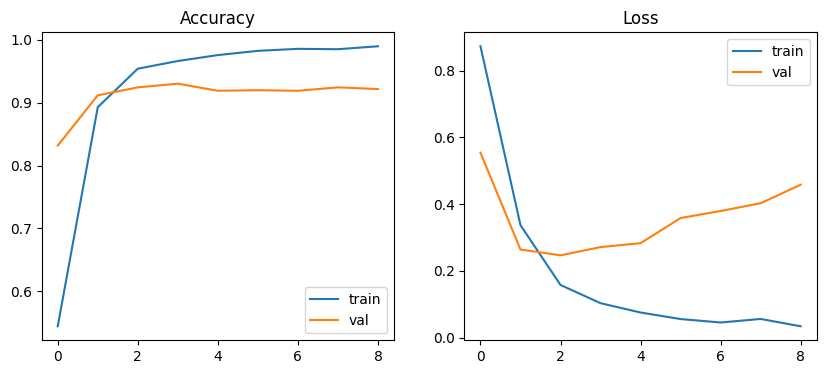


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93      2141
           1       0.95      0.94      0.94      2154
           2       0.82      0.90      0.86      1232

    accuracy                           0.92      5527
   macro avg       0.91      0.92      0.91      5527
weighted avg       0.92      0.92      0.92      5527



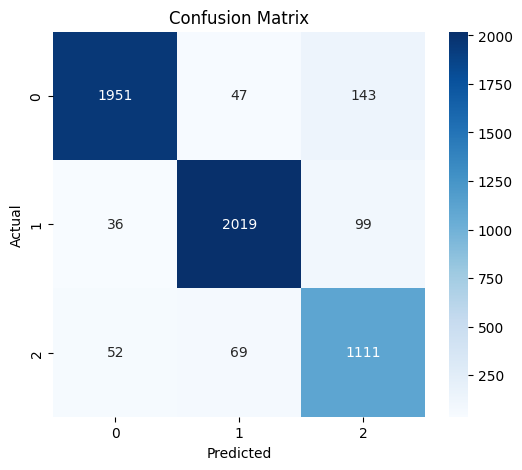

In [53]:
# Mengevaluasi model
y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Membuat plot akurasi dan plot loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['train','val'])
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['train','val'])
plt.show()

# Membuat visualisasi confusion matrix
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [54]:
# Simpan model
model.save("bilstm_attention_model.keras")

# Simpan tokenizer (INI FEATURE EXTRACTION NYA)
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Simpan max length
with open("maxlen.pkl", "wb") as f:
    pickle.dump(MAX_LEN, f) # Corrected from max_len to MAX_LEN

print("Model, tokenizer, dan MAX_LEN berhasil disimpan!")

Model, tokenizer, dan MAX_LEN berhasil disimpan!


### Interface dan Testing

In [55]:
# Pembuatan Attention
class AttentionLayer(Layer):
    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True
        )
        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

In [56]:
# Load tokenizer
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# Load maxlen
with open("maxlen.pkl", "rb") as f:
    max_len = pickle.load(f)

# Load model
model = load_model(
    "bilstm_attention_model.keras",
    custom_objects={"AttentionLayer": AttentionLayer}
)

print("Model berhasil di-load!")

Model berhasil di-load!


In [57]:
def predict_sentiment(sentences):
    sequences = tokenizer.texts_to_sequences(sentences)
    padded = pad_sequences(sequences, maxlen=max_len, padding='post')
    preds = model.predict(padded)
    label_mapping_reverse = {
        0: "negative",
        1: "neutral",
        2: "positive"
    }
    labels = [label_mapping_reverse[np.argmax(p)] for p in preds]
    return labels
new_sentences = [
    "aplikasi buruk hapus aja",
    "membantu banget mantap",
    "semoga aplikasinya digratiskan"
]
predicted_labels = predict_sentiment(new_sentences)
for s, l in zip(new_sentences, predicted_labels):
    print(f"Sentence: \"{s}\" - Predicted Label: {l}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
Sentence: "aplikasi buruk hapus aja" - Predicted Label: negative
Sentence: "membantu banget mantap" - Predicted Label: neutral
Sentence: "semoga aplikasinya digratiskan" - Predicted Label: positive


## TextCNN + Attention + Trainable Embedding (80/20)

In [58]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df["text_akhir"].astype(str)
y = clean_df["label"]

# Split ke 80/20
train_texts, test_texts, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
# Tokenisasi
MAX_WORDS = 20000
MAX_LEN = 100
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)
X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_test_seq = tokenizer.texts_to_sequences(test_texts)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post")
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

In [60]:
# Class weight
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.8605013233691421), 1: np.float64(0.855506539741506), 2: np.float64(1.4947937795807977)}


In [61]:
# Attetion
class AttentionLayer(tf.keras.layers.Layer):

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        score = tf.nn.tanh(tf.matmul(inputs, self.W))
        weights = tf.nn.softmax(score, axis=1)
        context = inputs * weights
        return tf.reduce_sum(context, axis=1)


In [62]:
EMBED_DIM = 128
input_layer = Input(shape=(MAX_LEN,))
embedding = Embedding(
    input_dim=vocab_size,
    output_dim=EMBED_DIM,
    trainable=True
    )(input_layer)
conv3 = Conv1D(128, 3, activation="relu", padding="same")(embedding)
conv4 = Conv1D(128, 4, activation="relu", padding="same")(embedding)
conv5 = Conv1D(128, 5, activation="relu", padding="same")(embedding)
att3 = AttentionLayer()(conv3)
att4 = AttentionLayer()(conv4)
att5 = AttentionLayer()(conv5)
concat = Concatenate()([att3, att4, att5])
dense = Dense(128, activation="relu")(concat)
drop = Dropout(0.5)(dense)
output = Dense(3, activation="softmax")(drop)
model = Model(inputs=input_layer, outputs=output)
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 100, 128)  │  1,477,376 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 100, 128)  │     49,280 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 128)  │     65,664 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 100, 128)  │     82,048 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer_2   │ (None, 128)       │        128 │ conv1d[0][0]      │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer_3   │ (None, 128)       │        128 │ conv1d_1[0][0]    │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer_4   │ (None, 128)       │        128 │ conv1d_2[0][0]    │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ attention_layer_… │
│ (Concatenate)       │                   │            │ attention_layer_… │
│                     │                   │            │ attention_layer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │        387 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,724,419 (6.58 MB)

 Trainable params: 1,724,419 (6.58 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# Callback
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_textcnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [64]:
# Training
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15


I0000 00:00:1770248777.515118     145 service.cc:152] XLA service 0x7ea7ec0f81e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770248777.515168     145 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770248777.515172     145 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-02-04 23:46:19.968257: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-04 23:46:20.234729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-04 23:46:21.171491: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time

 13/156 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3482 - loss: 1.0927

I0000 00:00:1770248785.234055     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


150/156 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4832 - loss: 0.9848

2026-02-04 23:46:27.548714: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-04 23:46:27.765640: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-04 23:46:28.092010: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-04 23:46:28.309235: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-04 23:46:28.854042: E external/local_xla/xla/stream_

156/156 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.4905 - loss: 0.9755 - val_accuracy: 0.8833 - val_loss: 0.3723
Epoch 2/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9146 - loss: 0.2813 - val_accuracy: 0.9177 - val_loss: 0.2606
Epoch 3/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9624 - loss: 0.1294 - val_accuracy: 0.9168 - val_loss: 0.2620
Epoch 4/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9712 - loss: 0.0964 - val_accuracy: 0.9276 - val_loss: 0.2939
Epoch 5/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9804 - loss: 0.0679 - val_accuracy: 0.9213 - val_loss: 0.3137
Epoch 6/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9861 - loss: 0.0499 - val_accuracy: 0.9218 - val_loss: 0.3612
Epoch 7/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9878 - loss: 0.0421 - val_accuracy: 0.9190 - val_loss: 0.3862
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy: 93.41%


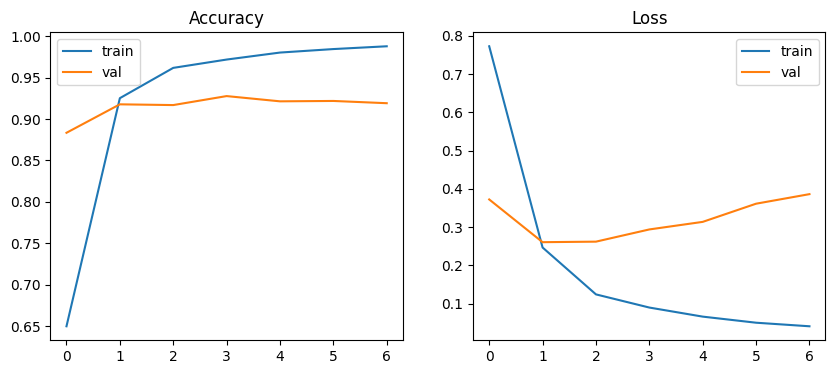


Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.95      0.95      2141
    positive       0.96      0.94      0.95      2154
     neutral       0.86      0.90      0.88      1232

    accuracy                           0.93      5527
   macro avg       0.93      0.93      0.93      5527
weighted avg       0.94      0.93      0.93      5527



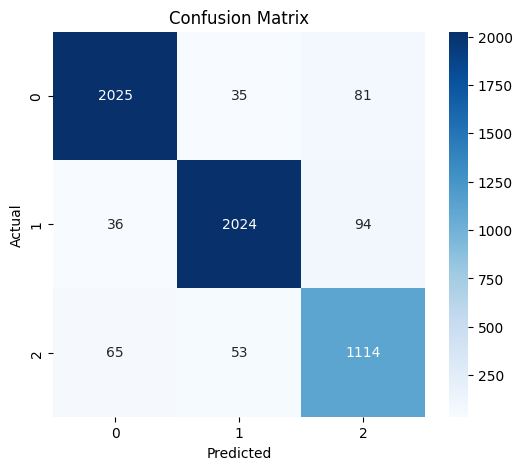

In [65]:
# Evaluasi model
y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Membuat plot akurasi dan plot loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['train','val'])
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['train','val'])
plt.show()

# Membuat visualisasi confusion matrix
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["negative", "positive", "neutral"]
))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [66]:
# Simpan model
model.save("textcnn_attention_model.keras")
with open("tokenizer_textcnn.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
print("Model dan tokenizer berhasil disimpan")

Model dan tokenizer berhasil disimpan


### Interface atau Testing

In [67]:
# Panggil model
loaded_model = tf.keras.models.load_model(
    "textcnn_attention_model.keras",
    custom_objects={"AttentionLayer": AttentionLayer}
)

with open("tokenizer_textcnn.pkl", "rb") as f:
    loaded_tokenizer = pickle.load(f)

label_map = {
    0: "negative",
    1: "positive",
    2: "neutral"
}

def predict_sentiment(texts):
    seq = loaded_tokenizer.texts_to_sequences(texts)
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post")

    preds = loaded_model.predict(pad)
    labels = np.argmax(preds, axis=1)

    return [label_map[i] for i in labels]

In [68]:
# Inference
new_sentences = ["aplikasi buruk hapus aja", "membantu banget mantap", "semoga aplikasinya digratiskan"]

predicted_labels = predict_sentiment(new_sentences)
for s, l in zip(new_sentences, predicted_labels):
    print(f"Sentence: \"{s}\" - Predicted Label: {l}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step
Sentence: "aplikasi buruk hapus aja" - Predicted Label: negative
Sentence: "membantu banget mantap" - Predicted Label: positive
Sentence: "semoga aplikasinya digratiskan" - Predicted Label: neutral


## Tambahan

In [69]:
!pip freeze requirements.txt

a2a-sdk==0.3.22
absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.11.0
aiofiles==22.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.17.0
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
ansicolors==1.1.8
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.18
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
args==0.1.0
array_record==0.8.1
arrow==1.4.0
arviz==0.22.0
asn1crypto==1.5.1
astropy==7.1.1
astropy-iers-data==0.2025.10.20.0.39.8
asttokens==3.0.1
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.0.1
Authlib==1.6.5
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
bayesian-optimization==3.2.0
beartype==0.22.2
beautifulsoup4==4.13.5
betterproto==2.0.0b7
bigframes==2.26.0
bigquery-magics==0.10.3
black==25.12.0
blake3==1.0.8
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blobfile==3.1.0
blosc2==3.10.2
bokeh==3.7.3
Boruta==0.4.3
boto3==1.42.27
botocore==1.4